In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
with zipfile.ZipFile("/content/brain_tumor_dataset.zip", mode='r') as archive:
  archive.extractall()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Attention
from tensorflow.keras.metrics import BinaryAccuracy, Recall, Precision
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import seaborn as sns

Found 253 files belonging to 2 classes.


<ipython-input-7-1847cac815fa>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[idx].set_title(f"Label: {int(batch[1][idx])}")  # Show corresponding label


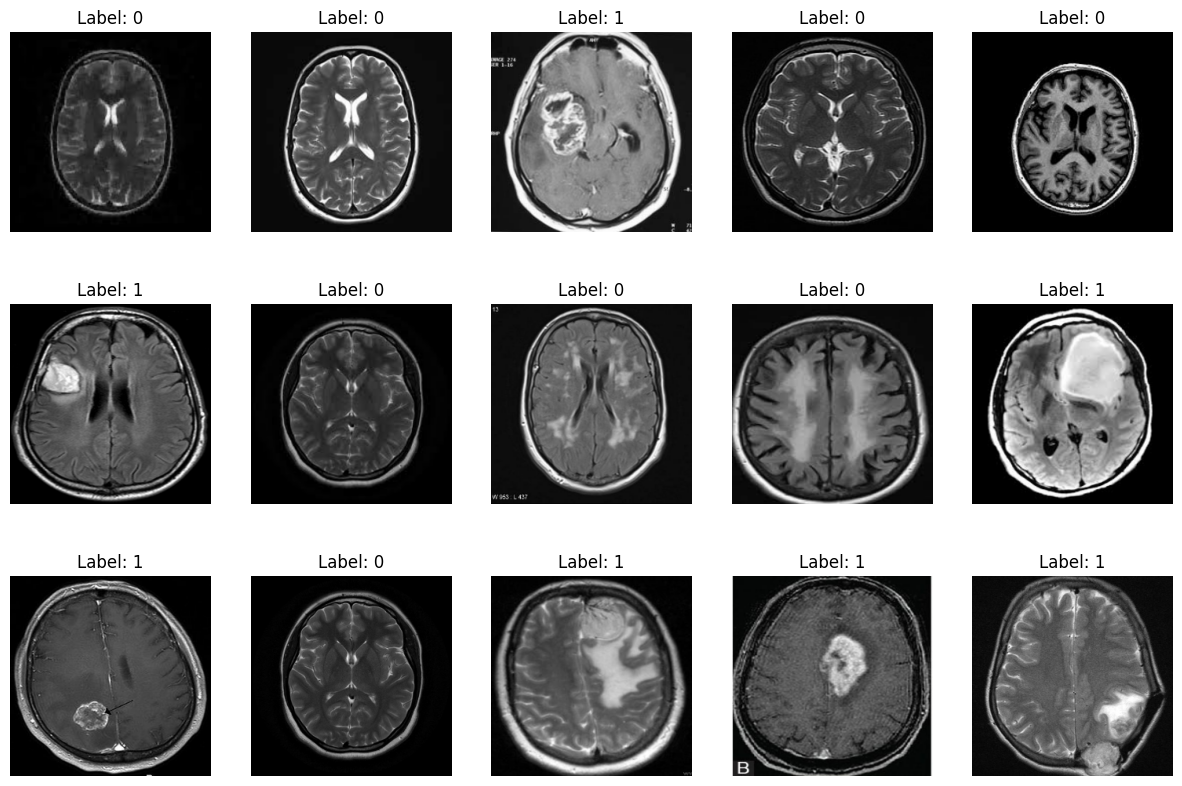

Min value: 0.0
Max value: 1.0
Train Size: 4
Validation Size: 2
Test Size: 2
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:

# Clear any existing session to prevent memory leaks
tf.keras.backend.clear_session()

# Load the dataset from a directory
data = keras.utils.image_dataset_from_directory("/content/brain_tumor_dataset",label_mode='binary',  # Assuming binary classification (0 for no tumor, 1 for tumor)
    image_size=(256, 256),  # Image dimensions
    batch_size=32,          # Batch size for training
)

# Display a few sample images from the dataset
# Fetch the first batch to visualize
batch = data.as_numpy_iterator().next()

# Create a plot to display sample images
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
ax = ax.flatten()  # Flatten axes for easier indexing

# Display the first 15 images with corresponding labels
for idx, img in enumerate(batch[0][:15]):
    ax[idx].imshow(img.astype(int))  # Ensure consistent data type (convert to int for display)
    ax[idx].set_title(f"Label: {int(batch[1][idx])}")  # Show corresponding label
    ax[idx].axis("off")  # Hide axis ticks

plt.show()  # Display the plot with sample images

# Normalize the data to scale images between 0 and 1
data = data.map(lambda x, y: (x / 255, y))  # Normalize images for consistency

# Verify the scaled data with a sample batch
scaled_batch = data.as_numpy_iterator().next()  # Get the next batch to check scaling
print("Min value:", scaled_batch[0].min())  # Check minimum value
print("Max value:", scaled_batch[0].max())  # Check maximum value

# Determine the dataset sizes for training, validation, and testing
total_batches = len(data)  # Total number of batches in the dataset
train_size = int(total_batches * 0.6)
val_size = int(total_batches * 0.2) + 1  # Add 1 to ensure no data is lost
test_size = int(total_batches * 0.2) + 1

print("Train Size:", train_size)  # Size for the training set
print("Validation Size:", val_size)  # Size for the validation set
print("Test Size:", test_size)  # Size for the test set

# Split the dataset into training, validation, and testing sets
train = data.take(train_size)  # First part for training
val = data.skip(train_size).take(val_size)  # Middle part for validation
test = data.skip(train_size + val_size).take(test_size)  # Last part for testing

# Define a deep learning model using a pre-trained ResNet-50 as the base
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))

# Freeze the base model's layers to retain pre-trained weights
for layer in base_model.layers:
    layer.trainable = False  # This prevents changing the pre-trained layers

# Add additional layers for the new task
attention = Attention()([base_model.output, base_model.output])  # Attention layer
flat = Flatten()(attention)  # Flatten the output for dense layers
dense1 = Dense(128, activation="relu")(flat)  # Dense layer with ReLU activation
output = Dense(1, activation="sigmoid")(dense1)  # Final output with sigmoid activation for binary classification

# Build the final model
model = keras.Model(inputs=base_model.input, outputs=output)  # Define the full model

# Compile the model with optimizer, loss function, and metrics
model.compile(optimizer=Adam(), loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])  # Use Adam optimizer and binary crossentropy


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 262, 262, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 64, 64, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 64, 64, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 40,365,185 (153.98 MB)

 Trainable params: 16,777,473 (64.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 253 files belonging to 2 classes.
Epoch 1/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 92s 23s/step - accuracy: 0.4781 - loss: 38.5981 - val_accuracy: 0.4531 - val_loss: 4.7399
Epoch 2/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 49s 14s/step - accuracy: 0.5208 - loss: 7.0623 - val_accuracy: 0.5781 - val_loss: 9.7028
Epoch 3/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 54s 16s/step - accuracy: 0.6958 - loss: 6.2171 - val_accuracy: 0.7188 - val_loss: 2.4269
Epoch 4/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 53s 15s/step - accuracy: 0.6156 - loss: 4.8472 - val_accuracy: 0.6562 - val_loss: 7.3274
Epoch 5/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 14s/step - accuracy: 0.7563 - loss: 4.0983 - val_accuracy: 0.5938 - val_loss: 5.0946
Epoch 6/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 54s 15s/step - accuracy: 0.6698 - loss: 5.2425 - val_accuracy: 0.7188 - val_loss: 4.1193
Epoch 7/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 51s 14s/step - accuracy: 0.7490 - loss: 4.6248 - val_accuracy: 0.7500 - val_loss: 3.9823
Epoch 8/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 49s 14s/step - accuracy: 0.7833 - loss: 2.4555 -

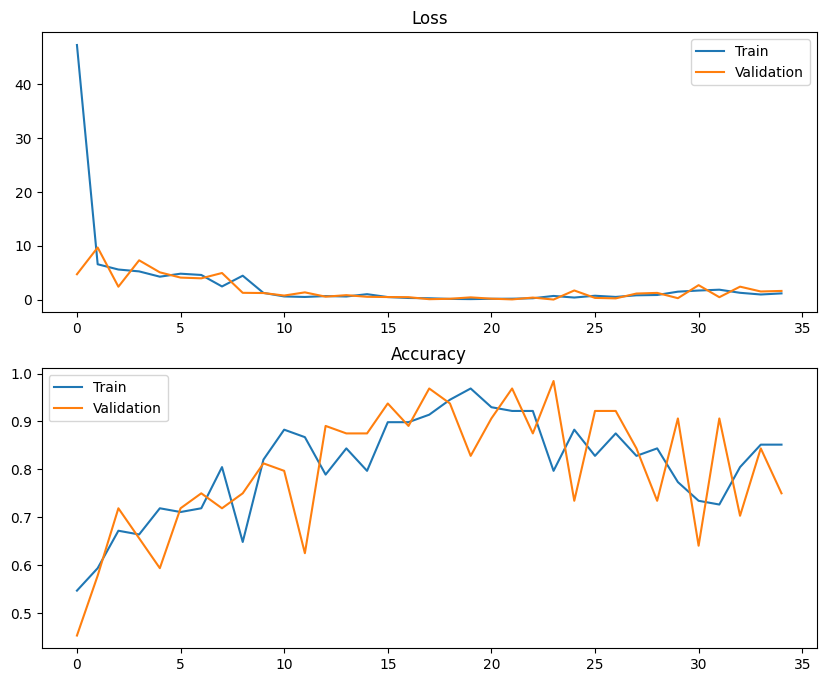

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score, auc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten, Attention, Reshape
from tensorflow.keras.optimizers import Adam

# Load the dataset
data = keras.utils.image_dataset_from_directory(
    "/content/brain_tumor_dataset",
    label_mode='binary',
    image_size=(256, 256),
    batch_size=32,
)
data = data.map(lambda x, y: (x / 255, y))

# Split the dataset into training, validation, and testing sets
total_batches = len(data)
train_size = int(total_batches * 0.6)
val_size = int(total_batches * 0.2) + 1
test_size = int(total_batches * 0.2) + 1

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# Define the model using ResNet50 as the base
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(256, 256, 3))
for layer in base_model.layers:
    layer.trainable = False

# Reshape the output of ResNet50 to match the Attention layer's expected input
reshaped_output = Reshape((-1, base_model.output.shape[-1]))(base_model.output)

# Apply the Attention layer
attention_output = Attention()([reshaped_output, reshaped_output])

# Flatten and add dense layers
flat = Flatten()(attention_output)
dense1 = Dense(128, activation="relu")(flat)
output = Dense(1, activation="sigmoid")(dense1)

# Build and compile the model
model = keras.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(), loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

# Train the model
history = model.fit(train, epochs=35, validation_data=val)

# Plot the training history
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(history.history["loss"], label="Train")
ax[0].plot(history.history["val_loss"], label="Validation")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(history.history["accuracy"], label="Train")
ax[1].plot(history.history["val_accuracy"], label="Validation")
ax[1].set_title("Accuracy")
ax[1].legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Accuracy: 0.8032787
Recall: 0.6857143
Precision: 0.96
F1 Score: 0.8
ROC-AUC Score: 0.9505494505494506


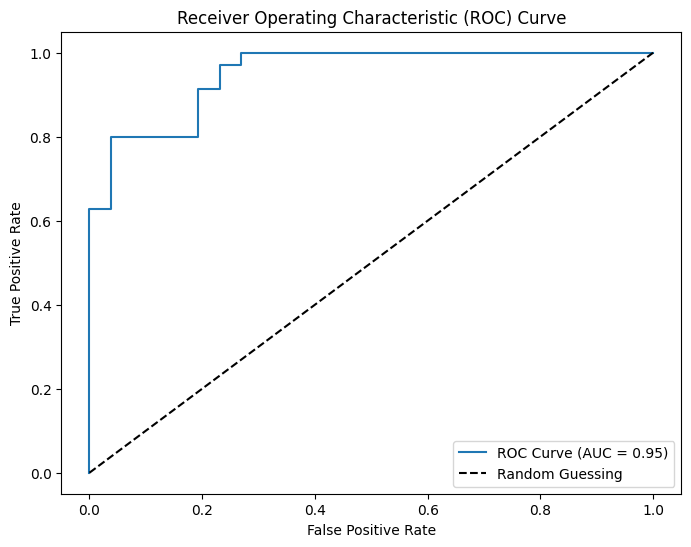

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.metrics import BinaryAccuracy, Recall, Precision

# Assuming you have a test dataset named 'test' and a model named 'model'

bin_acc = BinaryAccuracy()
recall = Recall()
precision = Precision()

y_true_list = []
y_pred_list = []

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    bin_acc.update_state(y, yhat)
    recall.update_state(y, yhat)
    precision.update_state(y, yhat)

    y_true_list.append(y)
    y_pred_list.append(yhat)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Calculate F1 Score
f1 = f1_score(y_true, (y_pred > 0.5).astype(int))

# Calculate ROC-AUC score
roc_auc = roc_auc_score(y_true, y_pred)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred)

# Calculate precision-recall curve
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred)

# Print all metrics
print("Accuracy:", bin_acc.result().numpy())
print("Recall:", recall.result().numpy())
print("Precision:", precision.result().numpy())
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()



  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

<ipython-input-13-49b05596cf7c>:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[0].set_title(f"Original Image - Label: {int(sample_label)}")


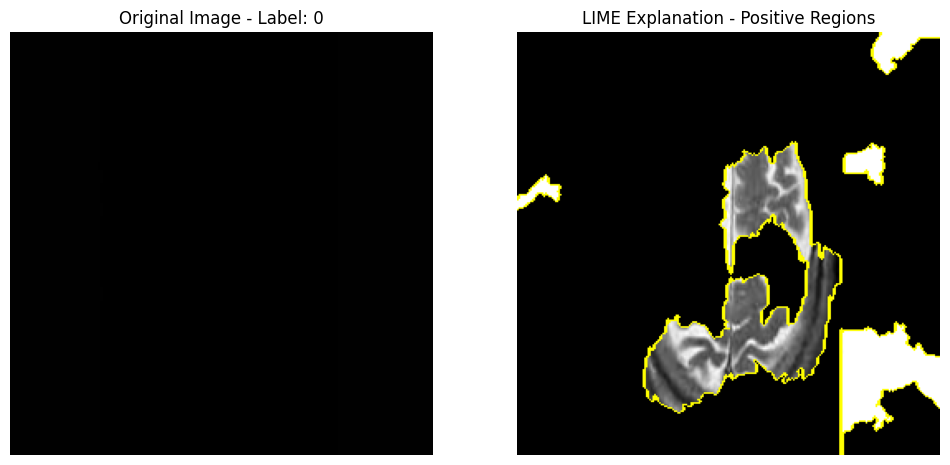

In [ ]:
import lime
import lime.lime_image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Function to make predictions for LIME
def predict_fn(images):
    """Return probabilities from the model."""
    # Normalize the images to [0, 1]
    images = images / 255
    predictions = model.predict(images)
    # Return probabilities and ensure correct shape for LIME
    return np.array([[1 - p[0], p[0]] for p in predictions])

# Create an explainer object for LIME
explainer = lime.lime_image.LimeImageExplainer()

# Get a sample image from the test dataset
sample_batch = test.as_numpy_iterator().next()
sample_image = sample_batch[0][0]  # First image from the batch
sample_label = sample_batch[1][0]  # Corresponding label

# Generate an explanation for the sample image
explanation = explainer.explain_instance(
    sample_image.astype('double'),  # Convert to double for LIME
    predict_fn,  # Prediction function for LIME
    top_labels=1,  # Number of top labels to explain
    hide_color=0,  # Color for hidden regions
    num_samples=1000,  # Number of perturbed samples
)

# Get the explanation for the top label
top_label = explanation.top_labels[0]  # Top predicted label
temp, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=True,
    num_features=10,
    hide_rest=True
)

# Display the original image and the LIME explanation
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image with label
ax[0].imshow(sample_image.astype(int))
ax[0].set_title(f"Original Image - Label: {int(sample_label)}")
ax[0].axis("off")

# LIME explanation with highlighted regions
ax[1].imshow(mark_boundaries(temp, mask))
ax[1].set_title("LIME Explanation - Positive Regions")
ax[1].axis("off")

plt.show()


In [ ]:
import lime
import lime.lime_image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Create an explainer object for LIME
explainer = lime.lime_image.LimeImageExplainer()

# Function to make predictions for LIME
def predict_fn(images):
    """Return probabilities from the model."""
    images = images / 255  # Normalize images to [0, 1]
    predictions = model.predict(images)
    # Return probabilities and ensure correct shape for LIME
    return np.array([[1 - p[0], p[0]] for p in predictions])

# Get a different sample image from the test dataset
sample_batch = test.as_numpy_iterator().next()  # Get a batch
sample_image = sample_batch[0][1]  # Take the second image from the batch
sample_label = sample_batch[1][1]  # Corresponding label

# Generate a LIME explanation for this new sample image
explanation = explainer.explain_instance(
    sample_image.astype('double'),  # Convert to double for LIME
    predict_fn,  # Prediction function for LIME
    top_labels=1,  # Number of top labels to explain
    hide_color=0,  # Color for hidden regions
    num_samples=1000  # Number of perturbed samples
)

# Get the explanation for the top label
top_label = explanation.top_labels[0]  # Top predicted label
temp, mask = explanation.get_image_and_mask(
    top_label,
    positive_only=True,
    num_features=10,
    hide_rest=True
)

# Display the original image and the LIME explanation for this new image
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image with label
ax[0].imshow(sample_image.astype(int))  # Ensure data type is int for display
ax[0].set_title(f"Original Image - Label: {int(sample_label)}")
ax[0].axis("off")

# LIME explanation with highlighted regions
ax[1].imshow(mark_boundaries(temp, mask))
ax[1].set_title("LIME Explanation - Positive Regions")
ax[1].axis("off")

plt.show()


REST NET 50 NO ATTENTION

In [ ]:
import cv2
import os
import numpy as np
import glob
import tensorflow as tf
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load the model
model = load_model("brain_tumor_resnet_no_attention.h5")

# Load test data
# Assuming x_test, y_test are already defined

# Make predictions
y_pred = model.predict(x_test)
y_pred_binary = np.round(y_pred).flatten()

# Calculate evaluation metrics
accuracy = np.mean(y_pred_binary == y_test)
conf_matrix = confusion_matrix(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

# Print evaluation metrics
print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("AUC:", auc)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# CNN

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load the dataset
data = keras.utils.image_dataset_from_directory('/content/brain_tumor_dataset')

Found 253 files belonging to 2 classes.


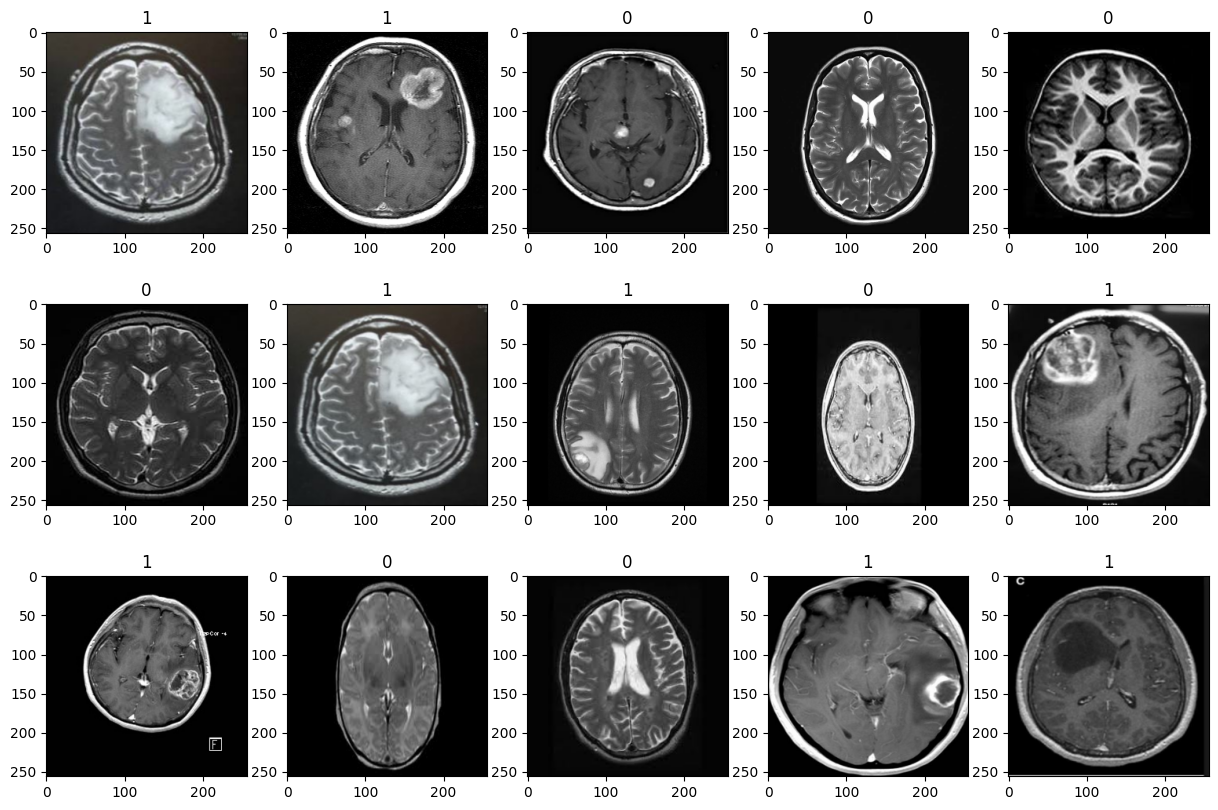

In [21]:
# Display sample images from the dataset
batch = data.as_numpy_iterator().next()
fig, ax = plt.subplots(3, 5, figsize=(15, 10))
ax = ax.flatten()
for idx, img in enumerate(batch[0][:15]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

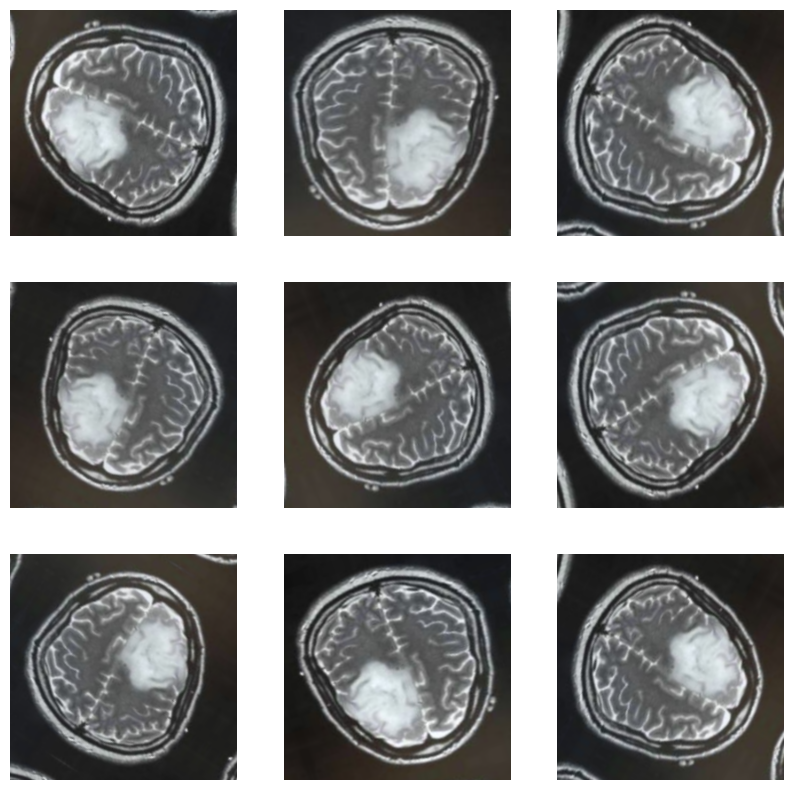

In [22]:
# Normalize and split the dataset
data = data.map(lambda x, y: (x / 255, y))
train_size = int(len(data) * 0.6)
val_size = int(len(data) * 0.2) + 1
test_size = int(len(data) * 0.2) + 1
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", input_shape=(256, 256, 3)),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomRotation(0.2)
])

# Display augmented images
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_image = data_augmentation(batch[0][0:1])  # Assuming `batch[0][0:1]` is an image
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")

In [23]:
# Define the model
model = keras.Sequential([
    data_augmentation,
    layers.Conv2D(16, (3, 3), 1, activation="relu", padding="same"),
    layers.Conv2D(16, (3, 3), 1, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (5, 5), 1, activation="relu", padding="same"),
    layers.Conv2D(32, (5, 5), 1, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(16, (3, 3), 1, activation="relu", padding="same"),
    layers.Conv2D(16, (3, 3), 1, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Compile the model
model.compile(optimizer="adam", loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 10s/step - accuracy: 0.4844 - loss: 0.6851 - val_accuracy: 0.6094 - val_loss: 0.5940
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 38s 10s/step - accuracy: 0.6042 - loss: 0.6117 - val_accuracy: 0.5938 - val_loss: 0.6599
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 37s 9s/step - accuracy: 0.7229 - loss: 0.5982 - val_accuracy: 0.6250 - val_loss: 0.6555
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 10s/step - accuracy: 0.6010 - loss: 0.6502 - val_accuracy: 0.7812 - val_loss: 0.5374
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step - accuracy: 0.7260 - loss: 0.5631 - val_accuracy: 0.7656 - val_loss: 0.4887
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 10s/step - accuracy: 0.6687 - loss: 0.6069 - val_accuracy: 0.7344 - val_loss: 0.5558
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 9s/step - accuracy: 0.7781 - loss: 0.5349 - val_accuracy: 0.7344 - val_loss: 0.5048
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 38s 9s/step - accuracy: 0.7604 - loss: 0.5208 - val_accuracy: 0.7500 - val_loss: 0.5313
Epoc

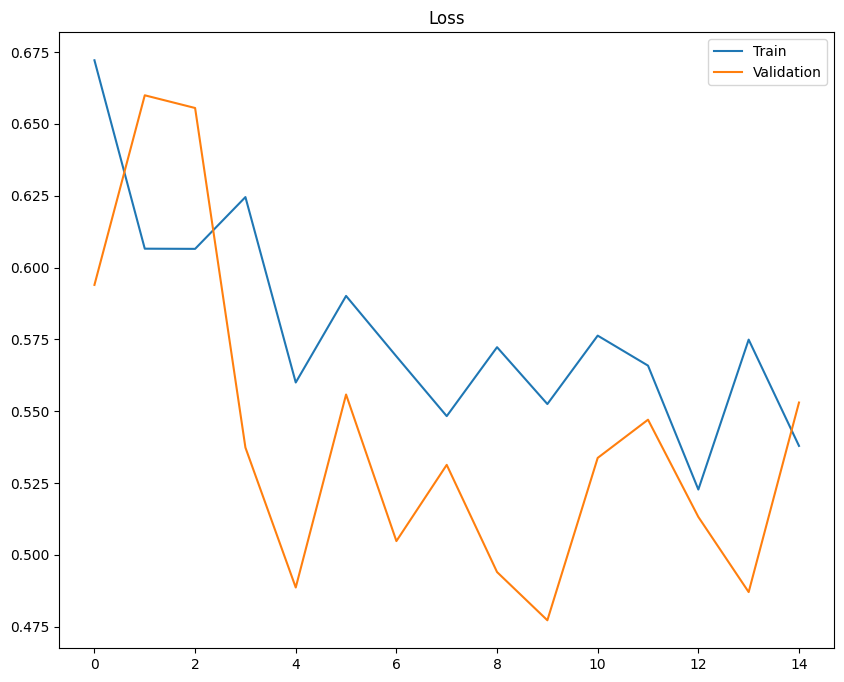

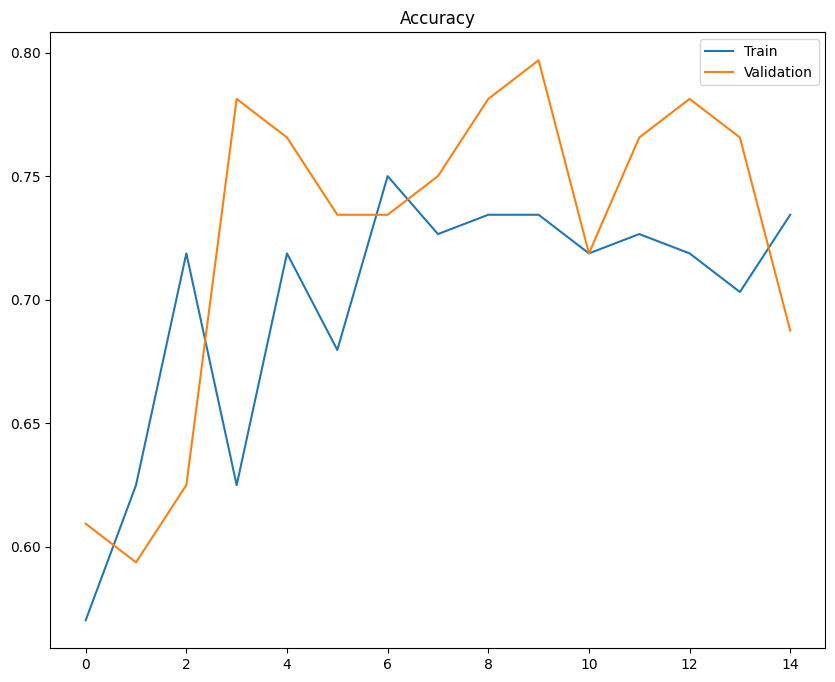

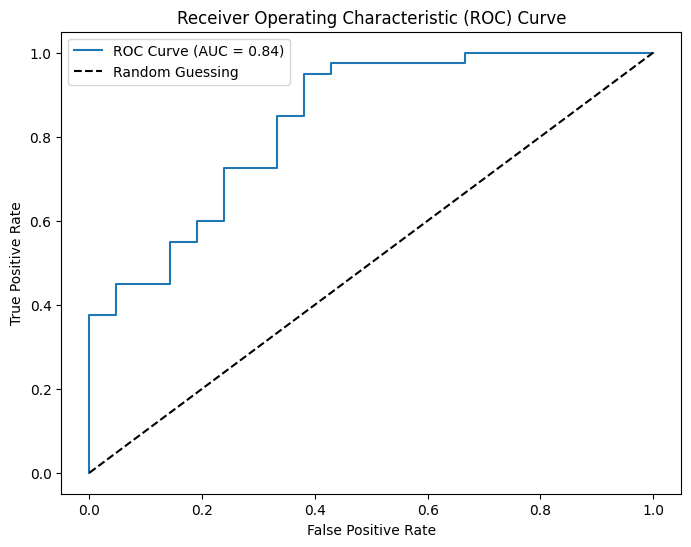

In [24]:
# Train the model
history = model.fit(train, epochs=15, validation_data=val)

# Visualize training history
plt.figure(figsize=(10, 8))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.figure(figsize=(10, 8))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

# Evaluate the model
bin_acc = keras.metrics.BinaryAccuracy()
recall = keras.metrics.Recall()
precision = keras.metrics.Precision()
y_true_list = []
y_pred_list = []

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    bin_acc.update_state(y, yhat)
    recall.update_state(y, yhat)
    precision.update_state(y, yhat)

    y_true_list.append(y)
    y_pred_list.append(yhat)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

roc_auc = roc_auc_score(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_pred)

# Print evaluation metrics
print("Accuracy:", bin_acc.result().numpy())
print("Recall:", recall.result().numpy())
print("Precision:", precision.result().numpy())
print("F1 Score:", f1_score(y_true, (y_pred > 0.5).astype(int)))
print("ROC-AUC Score:", roc_auc)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [25]:
# Calculate True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN)
TP = np.sum((y_true == 1) & (y_pred > 0.5))
TN = np.sum((y_true == 0) & (y_pred <= 0.5))
FP = np.sum((y_true == 0) & (y_pred > 0.5))
FN = np.sum((y_true == 1) & (y_pred <= 0.5))

# Calculate Sensitivity and Specificity
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)


Sensitivity: 0.7377049180327869
Specificity: 0.26229508196721313


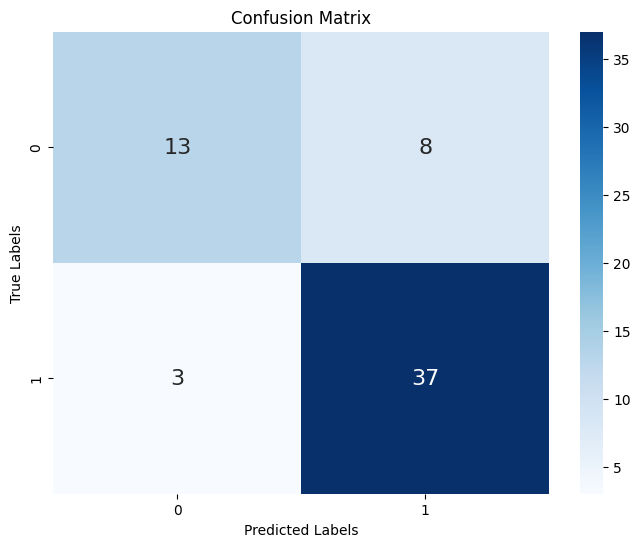

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, (y_pred > 0.5))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# VGG--19

Found 253 files belonging to 2 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 213s 59s/step - accuracy: 0.5312 - loss: 47.3838 - val_accuracy: 0.5781 - val_loss: 14.8076
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 207s 58s/step - accuracy: 0.6635 - loss: 10.3018 - val_accuracy: 0.7344 - val_loss: 4.6932
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 207s 59s/step - accuracy: 0.7406 - loss: 2.8267 - val_accuracy: 0.7656 - val_loss: 2.0355
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 189s 52s/step - accuracy: 0.7615 - loss: 1.7306 - val_accuracy: 0.6875 - val_loss: 3.4370
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 201s 52s/step - accuracy: 0.7844 - loss: 2.2773 - val_accuracy: 0.8750 - val_loss: 1.1363
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 205s 58s/step - accuracy: 0.8583 - loss: 0.8821 - val_accuracy: 0.9062 - val_loss: 0.5562
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 184s 51s/step - accuracy: 0.8625 - loss: 0.8844 - val_accuracy: 0.8594 - val_loss: 0.5962
Epoch 8/15
4/4 ━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 29s 29s/step
F1 Score: 0.9866666666666667
ROC-AUC Score: 0.9999999999999999


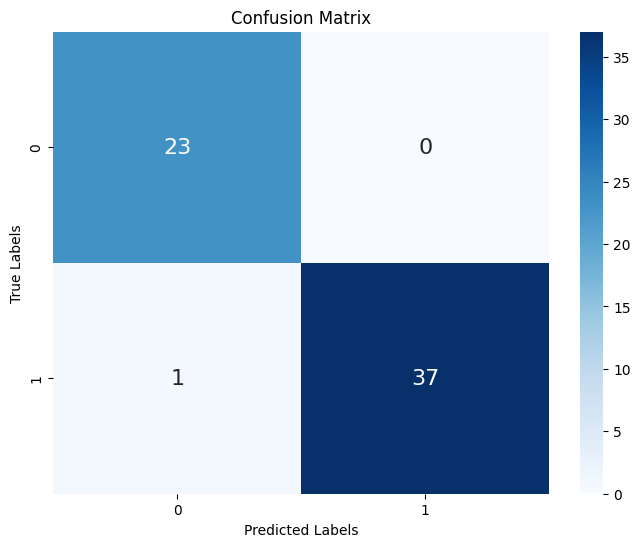

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
data = keras.utils.image_dataset_from_directory('/content/brain_tumor_dataset')

# Divide the dataset into train, validation, and test sets
train_size = int(len(data) * 0.6)
val_size = int(len(data) * 0.2) + 1
test_size = int(len(data) * 0.2) + 1

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# Define the VGG-19 model
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train, epochs=15, validation_data=val)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# Predictions
y_true_list = []
y_pred_list = []

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    y_true_list.append(y)
    y_pred_list.append(yhat)

y_true = np.concatenate(y_true_list, axis=0)
y_pred = np.concatenate(y_pred_list, axis=0)

# Calculate metrics
f1 = f1_score(y_true, (y_pred > 0.5).astype(int))
roc_auc = roc_auc_score(y_true, y_pred)

# Print metrics
print("F1 Score:", f1)
print("ROC-AUC Score:", roc_auc)

# Calculate confusion matrix
cm = confusion_matrix(y_true, (y_pred > 0.5).astype(int))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [40]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


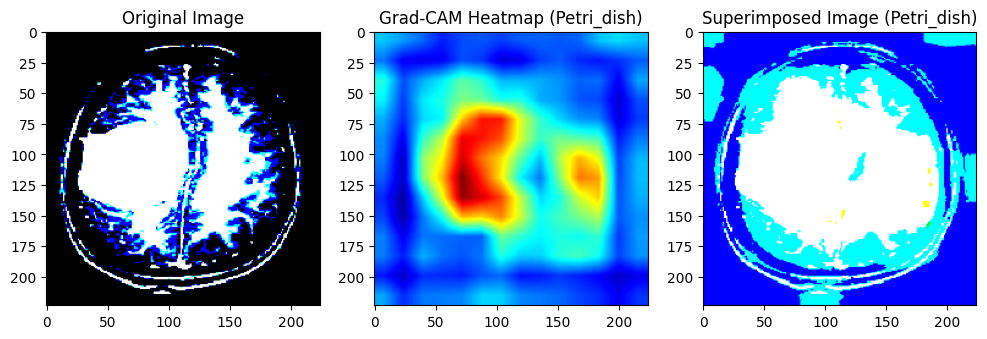

In [39]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load and preprocess an image
img_path = '/content/brain_tumor_dataset/yes/Y1.jpg'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get the top predicted class
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
pred_class_name = decode_predictions(preds)[0][0][1]

# Get the output tensor of the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

# Compute the gradient of the top predicted class with respect to the output feature map of the last conv layer
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)[0]

# Compute the CAM
cam = np.mean(conv_outputs[0], axis=-1)
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam / cam.max()

# Generate heatmap overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Superimpose the heatmap on the original image
superimposed_img = cv2.addWeighted(
    cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB).astype('float32'), 0.6,
    heatmap.astype('float32'), 0.4, 0
)
# Plot the original image, Grad-CAM heatmap, and the superimposed image
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title(f'Grad-CAM Heatmap ({pred_class_name})')
plt.imshow(heatmap)

plt.subplot(133)
plt.title(f'Superimposed Image ({pred_class_name})')
plt.imshow(superimposed_img)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


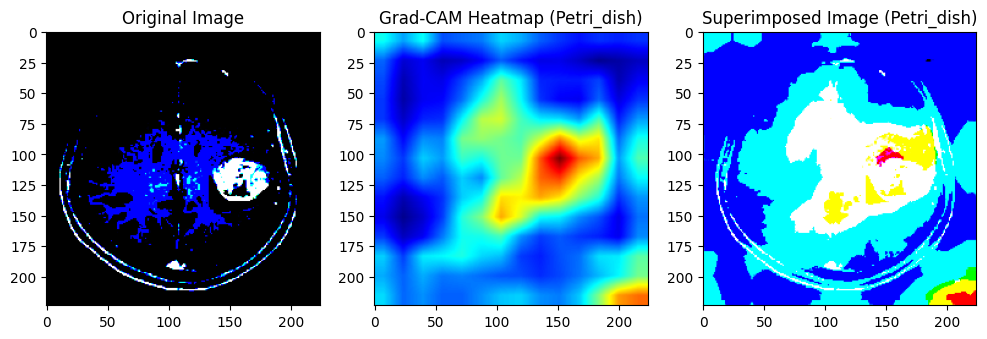

In [45]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load and preprocess an image
img_path = '/content/brain_tumor_dataset/yes/Y19.JPG'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get the top predicted class
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
pred_class_name = decode_predictions(preds)[0][0][1]

# Get the output tensor of the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

# Compute the gradient of the top predicted class with respect to the output feature map of the last conv layer
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)[0]

# Compute the CAM
cam = np.mean(conv_outputs[0], axis=-1)
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam / cam.max()

# Generate heatmap overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Superimpose the heatmap on the original image
superimposed_img = cv2.addWeighted(
    cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB).astype('float32'), 0.6,
    heatmap.astype('float32'), 0.4, 0
)
# Plot the original image, Grad-CAM heatmap, and the superimposed image
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title(f'Grad-CAM Heatmap ({pred_class_name})')
plt.imshow(heatmap)

plt.subplot(133)
plt.title(f'Superimposed Image ({pred_class_name})')
plt.imshow(superimposed_img)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step


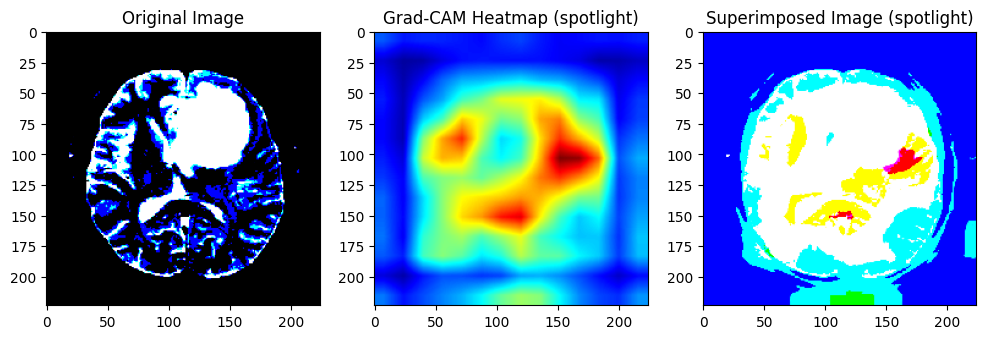

In [54]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import matplotlib.pyplot as plt

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet')

# Load and preprocess an image
img_path = '/content/brain_tumor_dataset/yes/Y66.JPG'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get the top predicted class
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
pred_class_name = decode_predictions(preds)[0][0][1]

# Get the output tensor of the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

# Compute the gradient of the top predicted class with respect to the output feature map of the last conv layer
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)[0]

# Compute the CAM
cam = np.mean(conv_outputs[0], axis=-1)
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224, 224))
cam = cam / cam.max()

# Generate heatmap overlay
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# Superimpose the heatmap on the original image
superimposed_img = cv2.addWeighted(
    cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB).astype('float32'), 0.6,
    heatmap.astype('float32'), 0.4, 0
)
# Plot the original image, Grad-CAM heatmap, and the superimposed image
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title(f'Grad-CAM Heatmap ({pred_class_name})')
plt.imshow(heatmap)

plt.subplot(133)
plt.title(f'Superimposed Image ({pred_class_name})')
plt.imshow(superimposed_img)
plt.show()